In [34]:
import numpy as np
from matplotlib import pyplot as plt, gridspec
from matplotlib import animation 
import pickle

In [24]:
path_to_test_progression = 'saved_models/run_1/test_progression.pickle'
with open(path_to_test_progression, 'rb') as f:
    test_progression = pickle.load(f)

In [27]:
# Convert images from torch tensor to numpy array
images = [i.detach().cpu().numpy() for i in test_progression]
len(images)

91

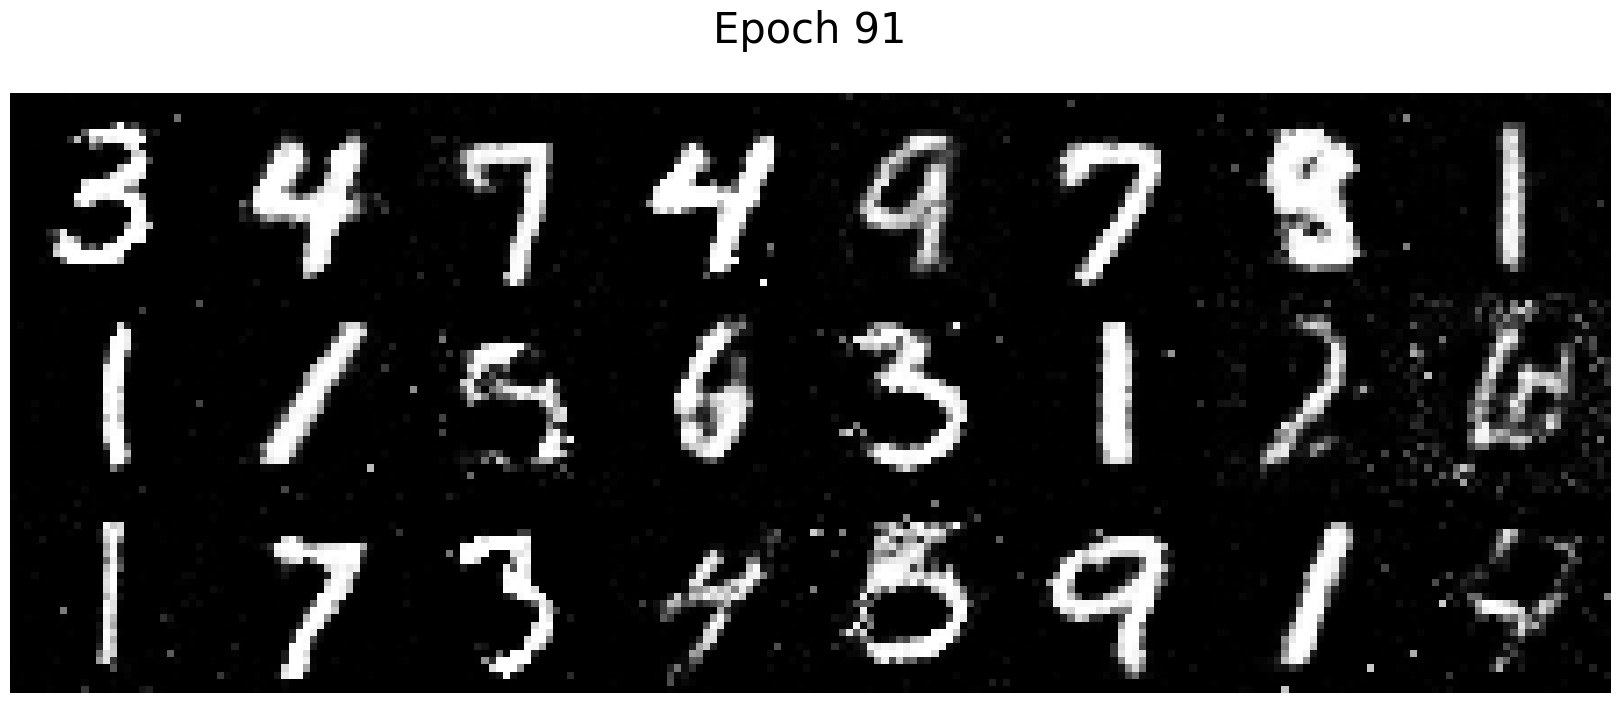

In [28]:
epoch_to_plot = len(images) # 100
nrow = 3
ncol = 8

# randomly select 10 images for plotting
indexes = np.random.choice(range(100), nrow * ncol, replace=False)

fig = plt.figure(figsize=((ncol+1)*2, (nrow+1)*2)) 
fig.suptitle('Epoch {}'.format(epoch_to_plot), fontsize=30)
gs = gridspec.GridSpec(nrow, ncol,
         wspace=0.0, hspace=0.0, 
         top=1.-0.5/(nrow+1), bottom=0.5/(nrow+1), 
         left=0.5/(ncol+1), right=1-0.5/(ncol+1)) 

for i in range(nrow):
    for j in range(ncol):
        idx = i*ncol + j
        img = np.reshape(images[epoch_to_plot-1][indexes[idx]], (28,28))
        ax = plt.subplot(gs[i,j])
        ax.imshow(img, cmap='gray')
        ax.axis('off')

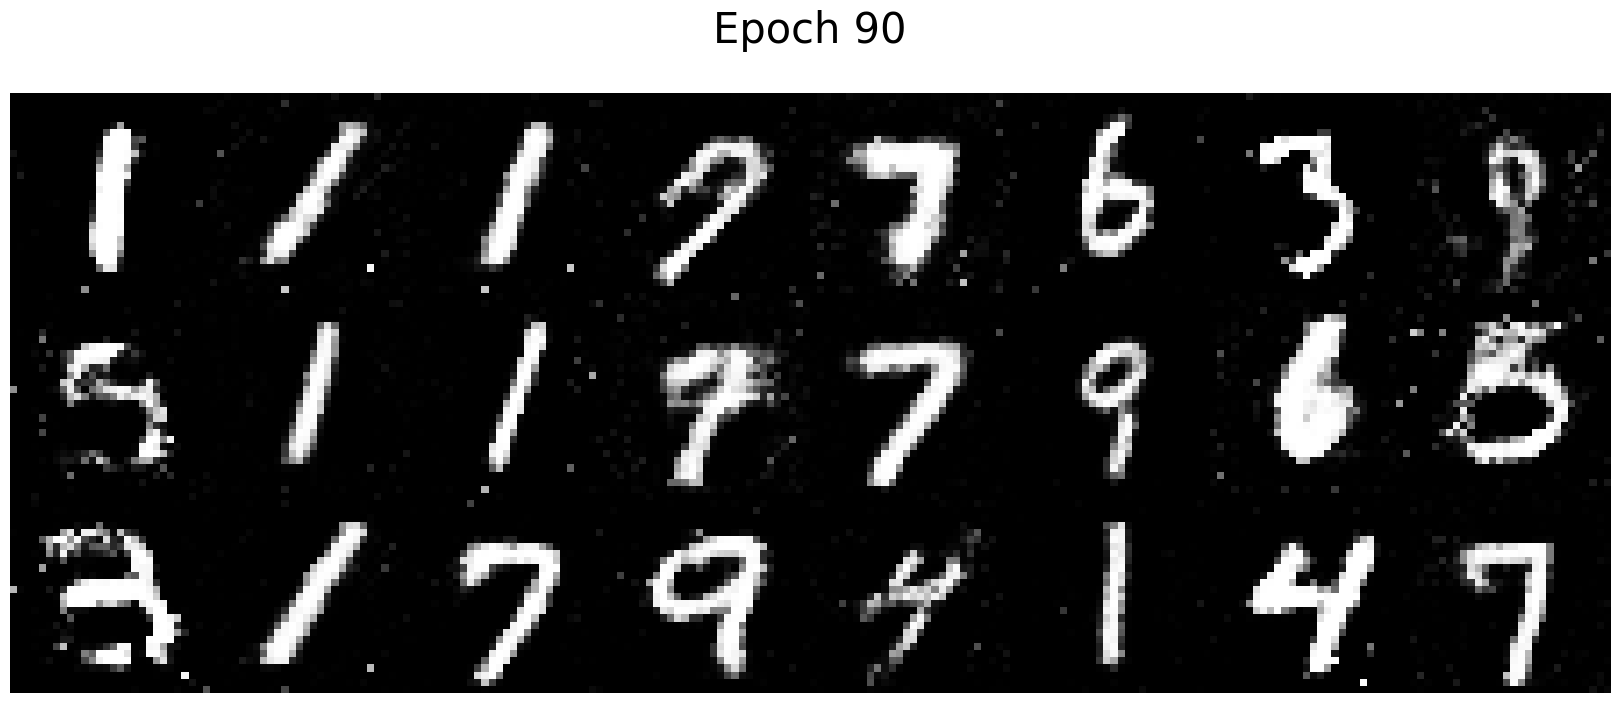

In [36]:
import numpy as np
from matplotlib import pyplot as plt, gridspec, rc
from matplotlib.animation import FuncAnimation
rc('animation', html='jshtml')

images = [i.detach().cpu().numpy() for i in test_progression]

nrow = 3
ncol = 8

indexes = np.random.choice(range(100), nrow*ncol, replace=False)

fig = plt.figure(figsize=((ncol+1)*2, (nrow+1)*2)) 

gs = gridspec.GridSpec(nrow, ncol,
         wspace=0.0, hspace=0.0, 
         top=1.-0.5/(nrow+1), bottom=0.5/(nrow+1), 
         left=0.5/(ncol+1), right=1-0.5/(ncol+1)) 

for i in range(nrow):
  for j in range(ncol):
    ax = plt.subplot(gs[i,j])
    ax.axis('off')

def animate(frame):
  fig.suptitle('Epoch {}'.format(frame), fontsize=30)
  ret = []
  for i in range(nrow):
    for j in range(ncol):
      idx = i*ncol + j
      img = np.reshape(images[frame][indexes[idx]], (28,28))
      ax = fig.axes[idx]
      ax.imshow(img, cmap='gray')
      ret.append(ax.get_images()[0])
  return ret
    
anim = FuncAnimation(fig, animate, frames=len(images), interval=50, blit=True)
# anim.save('doc/all_epoch.mp4', dpi=50, fps=5)
writergif = animation.PillowWriter(fps=15)
anim.save('doc/all_epoch.gif', writer=writergif)
